**Model:** Predict by elo.  
**Score:**  
Elo: 0.672.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Preparation

In [2]:
data = pd.read_csv('match_data_300_tourns_modified.csv')
data.head()

,player1,player2,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,...,p2_frames_played_1_year,p2_frames_won_1_year,p2_frames_played_3_years,p2_frames_won_3_years,score1,score2,match_result,win_percentage,tournament_id,date
0,Mark Allen,Ricky Walden,7,1580,1418,0.709992,0.599888,501,313,3345,...,45,25,1032,557,0,4,1.0,0.000000,1063,1.415318e+18
1,Stephen Maguire,Judd Trump,7,1563,1551,0.516401,0.507499,663,444,4995,...,122,79,1344,782,1,4,1.0,0.200000,1063,1.415059e+18
2,Mark Selby,Steve Davis,7,1592,1246,0.878716,0.703704,736,495,5330,...,8,2,581,286,4,1,0.0,0.800000,1063,1.415059e+18
3,Neil Robertson,Ali Carter,7,1546,1544,0.502734,0.501250,621,402,4581,...,11,5,876,499,4,0,0.0,1.000000,1063,1.415318e+18
4,Stuart Bingham,Ronnie O'Sullivan,7,1488,1663,0.275106,0.392337,744,462,5592,...,71,46,674,431,2,4,1.0,0.333333,1063,1.415146e+18


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34521 entries, 0 to 34520
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player1                   34521 non-null  object 
 1   player2                   34521 non-null  object 
 2   best_of                   34521 non-null  int64  
 3   player1_elo               34521 non-null  int64  
 4   player2_elo               34521 non-null  int64  
 5   elo_match_win_rate        34521 non-null  float64
 6   elo_frame_win_rate        34521 non-null  float64
 7   p1_matches_played         34521 non-null  int64  
 8   p1_matches_won            34521 non-null  int64  
 9   p1_frames_played          34521 non-null  int64  
 10  p1_frames_won             34521 non-null  int64  
 11  p2_matches_played         34521 non-null  int64  
 12  p2_matches_won            34521 non-null  int64  
 13  p2_frames_played          34521 non-null  int64  
 14  p2_fra

In [4]:
#Train test split
from sklearn.model_selection import train_test_split
data_train, data_test = train_test_split(data, 
                                        test_size = 0.2,
                                        shuffle=False)


In [5]:
#Create predictors and targets for training and cross-validation set
y_train = data_train['match_result']
y_test = data_test['match_result']

#To get the predictor, we exclude players' names (Strings), date, tournament ids and match results.
X_train = data_train.drop(['match_result', 'win_percentage', 'score1', 'score2', 'player1', 'player2', 'tournament_id', 'date'],
                           axis = 1)
X_test = data_test.drop(['match_result', 'win_percentage', 'score1', 'score2', 'player1', 'player2', 'tournament_id', 'date'],
                           axis = 1)

***

## Performance Metrics
Because the two classes in the target are symmetric (swapping player1 and player2 will exchange positive and negative but still represents the same match), we won't consider metrics such as presision, specificity and sensitivity since they are the same as accuracy score. We will only consider accuracy score.

In [6]:
#Import metrics
from sklearn.metrics import accuracy_score

In [7]:
#Create dictionaries to store the metrics.
accuracy_scores = {}

#Create a list to store all the models we consider.
models = {}

In [8]:
def print_avg_cv_metrics(model, model_name):
    """
    Given a model, computes and stores accuracy scores on the test set.
    """

    #Create an empty array to store the scores.
    print('Currently working on ' + model_name + '.')

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = accuracy_score(y_test, y_pred)

    print('The accuracy score of ' + model_name + ' is:', score)
    
    #Record the scores
    accuracy_scores[model_name] = score

    models[model_name] = model


***

### Model 0: Predict by Elo Rating

The elo rating model predicts the winner to the player with higher elo rating. If two players have the same elo ratings, it predicts player1 to win. 

In [9]:
#Performance on the training set
pred_by_elo_train = X_train['player1_elo'] < X_train['player2_elo']
score1 = accuracy_score(y_train, pred_by_elo_train)

print('The accuracy score of prediction by elo rating on the training set is:', score1)

#Performance on the test set
pred_by_elo = X_test['player1_elo'] < X_test['player2_elo']
score2 = accuracy_score(y_test, pred_by_elo)

print('The accuracy score of prediction by elo rating on the test set is:', score2)

#Record the scores
accuracy_scores['Predict by elo'] = score2

The accuracy score of prediction by elo rating on the training set is: 0.6826477404403245
The accuracy score of prediction by elo rating on the test set is: 0.6721216509775525


***

### Distribution of Correct and incorrect predictions

In [10]:
# We investigate between the distribution of correct and incorrect predictions by elo difference
elo_difference = X_test['player2_elo'] - X_test['player1_elo']

correct_index = y_test[pred_by_elo == y_test].index 
correct_pred = X_test.loc[correct_index]

inc_index = y_test[pred_by_elo != y_test].index 
inc_pred = X_test.loc[correct_index]


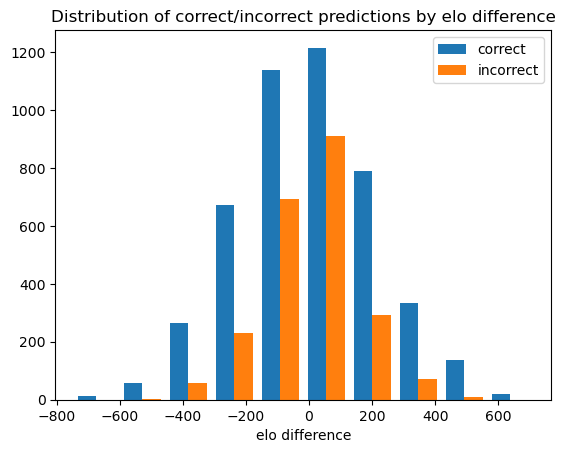

In [11]:
plt.hist([elo_difference.loc[correct_index], elo_difference.loc[inc_index]], label = ['correct', 'incorrect'])

plt.title('Distribution of correct/incorrect predictions by elo difference')
plt.legend()
plt.xlabel('elo difference')

plt.show()

We see that when elo difference is big, the model is more likely to predict the match result correctly.